In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
df=pd.read_csv("reviews.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048148 entries, 0 to 1048147
Data columns (total 23 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   recommendationid                1048148 non-null  int64  
 1   appid                           1048148 non-null  int64  
 2   author_steamid                  1048148 non-null  int64  
 3   author_num_games_owned          1048148 non-null  int64  
 4   author_num_reviews              1048148 non-null  int64  
 5   author_playtime_forever         1048145 non-null  float64
 6   author_playtime_last_two_weeks  1048145 non-null  float64
 7   author_playtime_at_review       869291 non-null   float64
 8   author_last_played              1048145 non-null  float64
 9   language                        1048148 non-null  object 
 10  review_text                     1047369 non-null  object 
 11  timestamp_created               1048148 non-null  int64  
 12  

In [4]:
df

,recommendationid,appid,author_steamid,author_num_games_owned,author_num_reviews,author_playtime_forever,author_playtime_last_two_weeks,author_playtime_at_review,author_last_played,language,...,voted_up,votes_up,votes_funny,weighted_vote_score,comment_count,steam_purchase,received_for_free,written_during_early_access,created_at,updated_at
0,10000000,264220,76561198085405844,760,74,12.0,0.0,12.0,1.399060e+09,polish,...,True,0,1,0.459906,0,True,False,False,2025-09-07 12:51:00.564782+00:00,2025-09-08 00:47:55.754043+00:00
1,100001066,1006440,76561198014439859,485,234,424.0,0.0,424.0,1.632666e+09,russian,...,True,8,0,0.630770,0,True,False,False,2025-09-07 12:51:00.564782+00:00,2025-09-08 00:47:55.754043+00:00
2,100002344,320721,76561198048038590,0,385,0.0,0.0,NaN,0.000000e+00,german,...,False,1,0,0.523810,0,True,False,False,2025-09-07 12:51:00.564782+00:00,2025-09-08 00:47:55.754043+00:00
3,100002361,1604700,76561197994386273,0,3,86.0,0.0,86.0,1.632674e+09,english,...,True,3,0,0.541985,0,True,False,False,2025-09-07 12:51:00.564782+00:00,2025-09-08 00:47:55.754043+00:00
4,100002504,1338560,76561198138996331,816,26,25.0,0.0,25.0,1.632639e+09,english,...,True,1,0,0.523810,0,True,False,False,2025-09-07 12:51:00.564782+00:00,2025-09-08 00:47:55.754043+00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1048143,9999845,295770,76561198007802821,357,8,364.0,0.0,193.0,1.435267e+09,english,...,True,1,0,0.502900,1,True,False,False,2025-09-07 12:51:00.564782+00:00,2025-09-08 03:11:58.033467+00:00
1048144,99998918,1689410,76561198866942343,340,623,5.0,0.0,5.0,1.632671e+09,english,...,False,2,2,0.545455,2,True,False,True,2025-09-07 12:51:00.564782+00:00,2025-09-08 03:11:58.033467+00:00
1048145,99999101,1517890,76561198025094738,0,96,602.0,0.0,44.0,1.676745e+09,english,...,True,0,0,0.500000,0,True,False,False,2025-09-07 12:51:00.564782+00:00,2025-09-08 03:11:58.033467+00:00
1048146,99999162,1121140,76561198054176508,0,18,112.0,0.0,112.0,1.632601e+09,german,...,True,3,0,0.552326,0,True,False,False,2025-09-07 12:51:00.564782+00:00,2025-09-08 03:11:58.033467+00:00


In [5]:
df.columns.tolist()

['recommendationid',
 'appid',
 'author_steamid',
 'author_num_games_owned',
 'author_num_reviews',
 'author_playtime_forever',
 'author_playtime_last_two_weeks',
 'author_playtime_at_review',
 'author_last_played',
 'language',
 'review_text',
 'timestamp_created',
 'timestamp_updated',
 'voted_up',
 'votes_up',
 'votes_funny',
 'weighted_vote_score',
 'comment_count',
 'steam_purchase',
 'received_for_free',
 'written_during_early_access',
 'created_at',
 'updated_at']

In [6]:
df_clean = df[df['language'] == 'english'].copy()

In [7]:
df_clean = df_clean[['review_text', 'voted_up']]




In [10]:
df_clean.reset_index(inplace=True)

In [11]:
df_clean

,index,review_text,voted_up
0,3,"It took me a grueling 18 months, but I built a...",True
1,4,incredibly simple game. it does get boring qui...,True
2,7,"If you enjoy text-based games, this is a must ...",True
3,8,very cool.,True
4,10,One of the best casual games in a long time! E...,True
...,...,...,...
556226,1048141,well lets start its not a bad game i did quite...,True
556227,1048143,"At first glance it looks pretty iffy, but I've...",True
556228,1048144,"This game is really, really far from being in ...",False
556229,1048145,"this is absolutely AMAZING, exactly what i alw...",True


In [12]:
df_clean.rename(columns={'review_text': 'text', 'voted_up': 'label'}, inplace=True)

In [13]:
df_clean.dropna(inplace=True)

In [14]:
df_clean['label'] = df_clean['label'].astype(int)

In [17]:
df_clean

,text,label
0,"It took me a grueling 18 months, but I built a...",1
1,incredibly simple game. it does get boring qui...,1
2,"If you enjoy text-based games, this is a must ...",1
3,very cool.,1
4,One of the best casual games in a long time! E...,1
...,...,...
556226,well lets start its not a bad game i did quite...,1
556227,"At first glance it looks pretty iffy, but I've...",1
556228,"This game is really, really far from being in ...",0
556229,"this is absolutely AMAZING, exactly what i alw...",1


In [20]:
print(df_clean['label'].value_counts())
print(df_clean['label'].value_counts(normalize=True))

label
1    420669
0    135169
Name: count, dtype: int64
label
1    0.756819
0    0.243181
Name: proportion, dtype: float64


In [22]:
if len(df_clean) > 10000:
    df_small = df_clean.sample(n=10000, random_state=42)
else:
    df_small = df_clean.copy()

output_filename = 'steam_reviews_10k_sample.csv'
df_small.to_csv(output_filename, index=False)

1. جاري تحميل البيانات...
2. جاري تحويل النصوص إلى مصفوفة أرقام (TF-IDF)...
   - حجم بيانات التدريب: 7880 صف
   - حجم بيانات الاختبار: 1971 صف

3. تدريب نموذج Naive Bayes...
✅ تم التدريب.
4. تدريب نموذج Logistic Regression...
✅ تم التدريب.

📊 تقرير النتائج النهائي

🔹 دقة Naive Bayes: 79.81%
              precision    recall  f1-score   support

           0       0.87      0.16      0.28       463
           1       0.79      0.99      0.88      1508

    accuracy                           0.80      1971
   macro avg       0.83      0.58      0.58      1971
weighted avg       0.81      0.80      0.74      1971


🔸 دقة Logistic Regression: 84.37%
              precision    recall  f1-score   support

           0       0.84      0.41      0.55       463
           1       0.84      0.98      0.91      1508

    accuracy                           0.84      1971
   macro avg       0.84      0.70      0.73      1971
weighted avg       0.84      0.84      0.82      1971



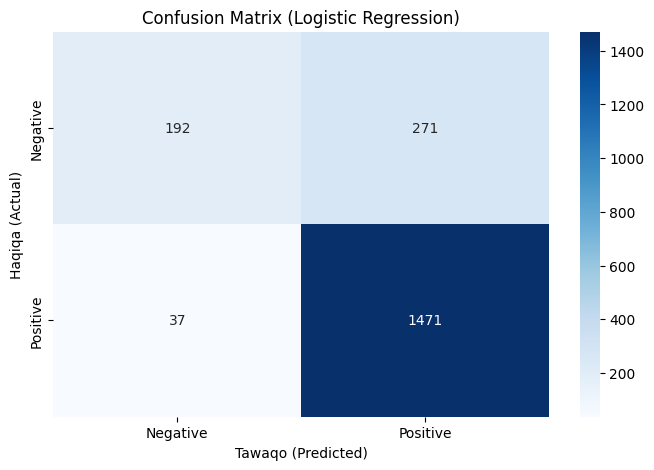

In [ ]:
print("1. جاري تحميل البيانات...")
df = pd.read_csv('steam_reviews_10k_cleaned.csv')

df.dropna(subset=['text_clean'], inplace=True)

X = df['text_clean']
y = df['label']

print("2. جاري تحويل النصوص إلى مصفوفة أرقام (TF-IDF)...")
tfidf = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

print(f"   - حجم بيانات التدريب: {X_train.shape[0]} صف")
print(f"   - حجم بيانات الاختبار: {X_test.shape[0]} صف")

print("\n3. تدريب نموذج Naive Bayes...")
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)
print("✅ تم التدريب.")

#  بناء نموذج Logistic Regression ---
print("4. تدريب نموذج Logistic Regression...")
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
print("✅ تم التدريب.")

# عرض النتائج والمقارنة ---
print("\n" + "="*40)
print("📊 تقرير النتائج النهائي")
print("="*40)

# Naive Bayes
acc_nb = accuracy_score(y_test, y_pred_nb)
print(f"\n🔹 دقة Naive Bayes: {acc_nb:.2%}")
print(classification_report(y_test, y_pred_nb))

# Logistic Regression
acc_lr = accuracy_score(y_test, y_pred_lr)
print(f"\n🔸 دقة Logistic Regression: {acc_lr:.2%}")
print(classification_report(y_test, y_pred_lr))

plt.figure(figsize=(8, 5))
cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Negative', 'Positive'], 
            yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix (Logistic Regression)')
plt.ylabel('Haqiqa (Actual)')
plt.xlabel('Tawaqo (Predicted)')
plt.show()

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.feature_extraction import text # لاستيراد قائمة الـ stop words الأصلية

print("1. جاري تحديث قائمة الكلمات المحظورة (Stop Words)...")
# سنضيف الكلمات العامة جداً التي خربت علينا النتائج
my_additional_stop_words = [
    'game', 'play', 'played', 'playing', 'games', 
    'good', 'great', 'best', 'bad', 'nice', 
    'really', 'like', 'love', 'fun', 'get', 
    'much', 'even', 'one', 'make', 'time', 'would', 'recommend'
]

# ندمج القائمة الأصلية مع قائمتنا الخاصة
stop_words = list(text.ENGLISH_STOP_WORDS.union(my_additional_stop_words))

print("2. إعادة تحويل النصوص لأرقام (بدون الكلمات المزعجة)...")
# نعيد تشغيل TF-IDF مع القائمة الجديدة
tfidf_v2 = TfidfVectorizer(max_features=5000, stop_words=stop_words)
X_tfidf_v2 = tfidf_v2.fit_transform(df['text_clean'])

print("3. تطبيق K-Means مرة أخرى...")
# نطلب 3 مجموعات
true_k = 3
model_v2 = KMeans(n_clusters=true_k, init='k-means++', max_iter=100, n_init=1, random_state=42)
model_v2.fit(X_tfidf_v2)

print("✅ تم التجميع الجديد!\n")

# عرض الكلمات المميزة للمجموعات الجديدة
print("--- 🔍 اكتشاف مواضيع المجموعات (بعد التعديل) ---")
order_centroids = model_v2.cluster_centers_.argsort()[:, ::-1]
terms = tfidf_v2.get_feature_names_out()

for i in range(true_k):
    print(f"\n🔹 المجموعة رقم {i+1}:")
    # طباعة أهم 10 كلمات
    top_words = [terms[ind] for ind in order_centroids[i, :10]]
    print(", ".join(top_words))

1. جاري تحديث قائمة الكلمات المحظورة (Stop Words)...
2. إعادة تحويل النصوص لأرقام (بدون الكلمات المزعجة)...
3. تطبيق K-Means مرة أخرى...
✅ تم التجميع الجديد!

--- 🔍 اكتشاف مواضيع المجموعات (بعد التعديل) ---

🔹 المجموعة رقم 1:
worth, buy, dlc, amaz, pretti, cool, littl, awesom, better, friend

🔹 المجموعة رقم 2:
dont, level, work, lot, feel, look, need, im, thing, way

🔹 المجموعة رقم 3:
realli, stori, puzzl, enjoy, charact, gameplay, short, littl, look, feel


جاري حساب إحداثيات الرسم (PCA)...


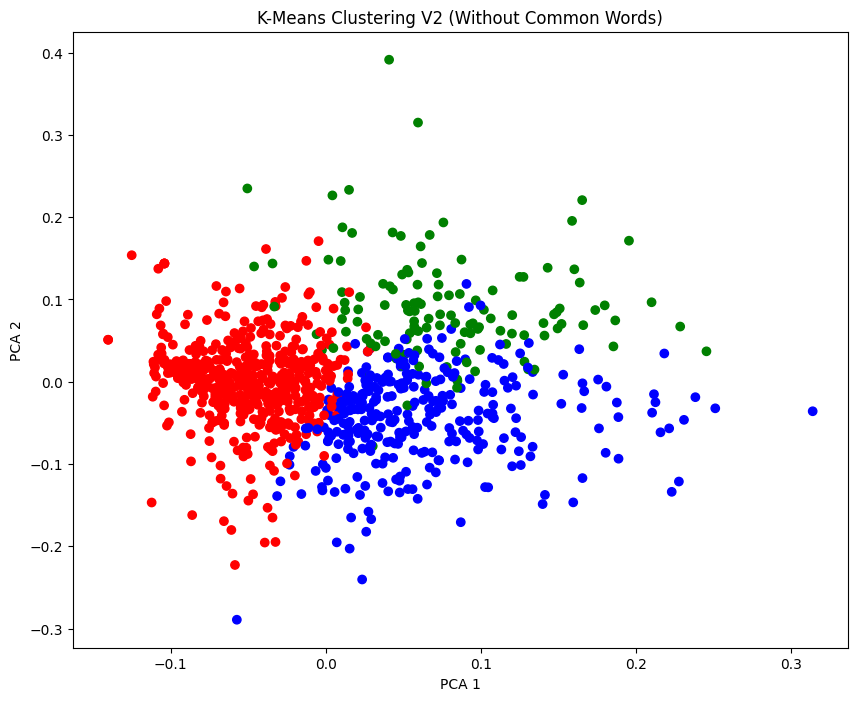

In [12]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 1. تقليل الأبعاد للرسم (من آلاف الكلمات إلى بعدين فقط X و Y)
# نستخدم X_tfidf_v2 (البيانات الجديدة المعدلة)
print("جاري حساب إحداثيات الرسم (PCA)...")
pca = PCA(n_components=2)
# نحول البيانات لمصفوفة عادية لأن PCA يحتاجها كذلك
scatter_plot_points = pca.fit_transform(X_tfidf_v2.toarray())

# 2. إعداد الألوان والمحاور
colors = ["r", "b", "g"]  # أحمر، أزرق، أخضر
x_axis = [o[0] for o in scatter_plot_points]
y_axis = [o[1] for o in scatter_plot_points]

# 3. الرسم
plt.figure(figsize=(10, 8))

# نرسم عينة (أول 1000 نقطة) عشان الرسمة تكون واضحة
limit = 1000 
plt.scatter(x_axis[:limit], y_axis[:limit], c=[colors[d] for d in model_v2.labels_[:limit]])

plt.title('K-Means Clustering V2 (Without Common Words)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.show()